# Time Series Forecasting for Portfolio Management Optimization

## 1. Business Objective

## 2. Import Libraries

## 3. Data Extraction

## 4. Data Loading

## 5. Data Cleaning

## 6. Data Understanding

## 7. Exploratory Data Analysis (EDA)

## 8. Feature Engineering

## 9. Stationarity Analysis

## 10. Risk Analysis

## 11. Key Insights

## 12. Conclusion

# Time Series Forecasting for Portfolio Management Optimization

## Business Objective

Guide Me in Finance (GMF) Investments aims to improve portfolio management by forecasting future market behavior using historical financial data. This project analyzes three financial assets (TSLA, SPY, and BND), develops forecasting models, and applies Modern Portfolio Theory (MPT) to recommend an optimal investment portfolio while balancing expected return and risk.

## 2. Import Libraries

In [11]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look professional
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

# Allow notebook to import from src/
sys.path.append("..")

from src.data_loader import (
    download_data,
    download_multiple_assets,
    load_data,
    save_data
)
from src.preprocessing import (
    preprocess_data,
    calculate_daily_returns,
    calculate_rolling_statistics,
    save_processed_data
)
from src.eda import (
    plot_closing_price,
    plot_daily_returns,
    plot_rolling_statistics,
    plot_return_distribution,
    plot_correlation_heatmap,
    detect_outliers,
    plot_volatility
)

## 3. Data Extraction

In [3]:
TICKERS = ["TSLA", "SPY", "BND"]

START_DATE = "2015-01-01"

END_DATE = "2026-06-30"

In [4]:
datasets = download_multiple_assets(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [5]:
for ticker, df in datasets.items():
    print("=" * 60)
    print(f"{ticker}")
    print("=" * 60)

    print(df.head())

    print()

    print("Shape:", df.shape)

    print()

TSLA
Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667   
1     2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000   
2     2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333   
3     2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333   
4     2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333   

Price    Volume  
0      71466000  
1      80527500  
2      93928500  
3      44526000  
4      51637500  

Shape: (2888, 7)

SPY
Price       Date        Open        High         Low       Close   Adj Close  \
0     2015-01-02  206.380005  206.880005  204.179993  205.429993  169.687836   
1     2015-01-05  204.169998  204.369995  201.350006  201.720001  166.623352   
2     2015-01-06  202.089996  202.720001  198.860001  199.820007  165.053894   
3     2015-01-07  201.419998  202.720001  200.880005  202.309998  167.110672   
4     2015-01

In [6]:
for ticker, df in datasets.items():

    print(f"\n{ticker}")

    print(df.info())


TSLA
<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       2888 non-null   datetime64[s]
 1   Open       2888 non-null   float64      
 2   High       2888 non-null   float64      
 3   Low        2888 non-null   float64      
 4   Close      2888 non-null   float64      
 5   Adj Close  2888 non-null   float64      
 6   Volume     2888 non-null   int64        
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 158.1 KB
None

SPY
<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       2888 non-null   datetime64[s]
 1   Open       2888 non-null   float64      
 2   High       2888 non-null   float64      
 3   Low        2888 non-null   float64      
 4   Close      2888 non-null   fl

In [7]:
for ticker, df in datasets.items():

    print(f"\nSummary Statistics for {ticker}")

    display(df.describe())


Summary Statistics for TSLA


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,2888,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,2020-09-27 06:13:27,148.797341,151.990563,145.416731,148.773923,148.773923,1.087922e+08
min,2015-01-02 00:00:00,9.488000,10.331333,9.403333,9.578000,9.578000,1.062000e+07
25%,2017-11-12 06:00:00,18.390833,18.665168,18.023666,18.393499,18.393499,6.548325e+07
50%,2020-09-26 12:00:00,131.496330,136.053329,125.831669,133.437668,133.437668,9.033615e+07
75%,2023-08-10 06:00:00,251.680004,257.485008,245.832500,251.925831,251.925831,1.261204e+08
max,2026-06-29 00:00:00,489.880005,498.829987,485.329987,489.880005,489.880005,9.140820e+08
std,NaN,138.977191,141.852818,135.867193,138.895957,138.895957,7.082549e+07



Summary Statistics for SPY


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,2888,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,2020-09-27 06:13:27,375.149543,377.167216,372.946586,375.216714,351.505532,8.551049e+07
min,2015-01-02 00:00:00,182.339996,184.100006,181.020004,182.860001,154.161652,2.027000e+07
25%,2017-11-12 06:00:00,254.577503,255.919998,252.477497,254.559998,223.546825,5.836455e+07
50%,2020-09-26 12:00:00,339.835007,342.315002,337.165009,339.435013,312.817902,7.541950e+07
75%,2023-08-10 06:00:00,453.989990,456.000000,451.549988,453.677498,432.806816,9.882245e+07
max,2026-06-29 00:00:00,758.150024,760.400024,756.750000,759.570007,757.618225,5.072443e+08
std,NaN,146.558911,147.244714,145.774814,146.584697,155.443934,4.338553e+07



Summary Statistics for BND


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,2888,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,2020-09-27 06:13:27,79.330661,79.442119,79.211198,79.327722,66.503052,4.653786e+06
min,2015-01-02 00:00:00,68.080002,68.379997,67.989998,68.040001,58.729256,0.000000e+00
25%,2017-11-12 06:00:00,73.800003,73.919998,73.639999,73.800003,62.478064,2.233700e+06
50%,2020-09-26 12:00:00,80.800003,80.905003,80.709999,80.814999,65.728382,4.280650e+06
75%,2023-08-10 06:00:00,83.470001,83.550003,83.332500,83.440002,70.689148,6.246475e+06
max,2026-06-29 00:00:00,89.550003,89.589996,89.440002,89.480003,74.832901,3.396300e+07
std,NaN,5.313805,5.298010,5.322546,5.310424,4.713606,3.017704e+06


In [8]:
import os

os.listdir("../data/raw")

['BND.csv', 'SPY.csv', 'TSLA.csv']

In [9]:
import os

os.listdir("../data/raw")

['BND.csv', 'SPY.csv', 'TSLA.csv']

In [ ]:
import os

print(os.getcwd())

c:\Users\HP\portfolio-optimization\notebooks


In [11]:
datasets = download_multiple_assets(
    tickers=["TSLA", "SPY", "BND"],
    start_date="2015-01-01",
    end_date="2026-06-30"
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [12]:
for t, df in datasets.items():
    print(t)
    print(df.columns)
    print()

TSLA
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str', name='Price')

SPY
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str', name='Price')

BND
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str', name='Price')



## 4. Data Loading and Preprocessing

In [15]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_daily_returns(
        cleaned_datasets[ticker]
    )

print("Daily returns calculated.")

Daily returns calculated.


In [16]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_rolling_statistics(
        cleaned_datasets[ticker]
    )

print("Rolling statistics calculated.")

Rolling statistics calculated.


In [17]:
for ticker, df in cleaned_datasets.items():

    save_processed_data(
        df=df,
        ticker=ticker
    )

print("Processed datasets saved.")

✓ Saved processed TSLA data to data\processed\TSLA_processed.csv
✓ Saved processed SPY data to data\processed\SPY_processed.csv
✓ Saved processed BND data to data\processed\BND_processed.csv
Processed datasets saved.


In [18]:
for ticker, df in cleaned_datasets.items():

    print("=" * 60)
    print(ticker)
    print("=" * 60)

    print(df.head())

    print()

    print(df.info())

    print()

    print(df.isnull().sum())

TSLA
Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667   
1     2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000   
2     2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333   
3     2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333   
4     2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333   

Price    Volume  Daily Return  Rolling Mean  Rolling Std  
0      71466000      0.000000           NaN          NaN  
1      80527500     -0.042041           NaN          NaN  
2      93928500      0.005664           NaN          NaN  
3      44526000     -0.001562           NaN          NaN  
4      51637500     -0.001564           NaN          NaN  

<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----    

In [19]:
for ticker, df in cleaned_datasets.items():

    save_processed_data(
        df=df,
        ticker=ticker
    )

print("Processed datasets saved.")

✓ Saved processed TSLA data to data\processed\TSLA_processed.csv
✓ Saved processed SPY data to data\processed\SPY_processed.csv
✓ Saved processed BND data to data\processed\BND_processed.csv
Processed datasets saved.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

sys.path.append("..")

from src.data_loader import (
    download_data,
    download_multiple_assets,
    load_data,
    save_data
)

from src.preprocessing import (
    preprocess_data,
    calculate_daily_returns,
    calculate_rolling_statistics,
    save_processed_data
)

In [4]:
TICKERS = ["TSLA", "SPY", "BND"]

START_DATE = "2015-01-01"

END_DATE = "2026-06-30"

In [5]:
datasets = download_multiple_assets(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [6]:
cleaned_datasets = {}

for ticker, df in datasets.items():
    cleaned_df = preprocess_data(df)
    cleaned_datasets[ticker] = cleaned_df

print("All datasets cleaned successfully!")

All datasets cleaned successfully!


In [7]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_daily_returns(
        cleaned_datasets[ticker]
    )

print("Daily returns calculated.")

Daily returns calculated.


In [8]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_rolling_statistics(
        cleaned_datasets[ticker]
    )

print("Rolling statistics calculated.")

Rolling statistics calculated.


In [9]:
for ticker, df in cleaned_datasets.items():

    save_processed_data(
        df=df,
        ticker=ticker
    )

print("Processed datasets saved.")

✓ Saved processed TSLA data to:
C:\Users\HP\portfolio-optimization\data\processed\TSLA_processed.csv
✓ Saved processed SPY data to:
C:\Users\HP\portfolio-optimization\data\processed\SPY_processed.csv
✓ Saved processed BND data to:
C:\Users\HP\portfolio-optimization\data\processed\BND_processed.csv
Processed datasets saved.


## 5. Exploratory Data Analysis (EDA)

In [12]:
TICKERS = ["TSLA", "SPY", "BND"]
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

datasets = download_multiple_assets(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [13]:
cleaned_datasets = {}

for ticker, df in datasets.items():
    cleaned_datasets[ticker] = preprocess_data(df)

print("Cleaning done")

Cleaning done


In [14]:
for ticker in cleaned_datasets:
    cleaned_datasets[ticker] = calculate_daily_returns(cleaned_datasets[ticker])

print("Daily returns added")

Daily returns added


In [15]:
for ticker in cleaned_datasets:
    cleaned_datasets[ticker] = calculate_rolling_statistics(cleaned_datasets[ticker])

print("Rolling stats added")

Rolling stats added


In [16]:
for ticker, df in cleaned_datasets.items():
    save_processed_data(df, ticker)

print("Saved processed datasets")

✓ Saved processed TSLA data to:
C:\Users\HP\portfolio-optimization\data\processed\TSLA_processed.csv
✓ Saved processed SPY data to:
C:\Users\HP\portfolio-optimization\data\processed\SPY_processed.csv
✓ Saved processed BND data to:
C:\Users\HP\portfolio-optimization\data\processed\BND_processed.csv
Saved processed datasets


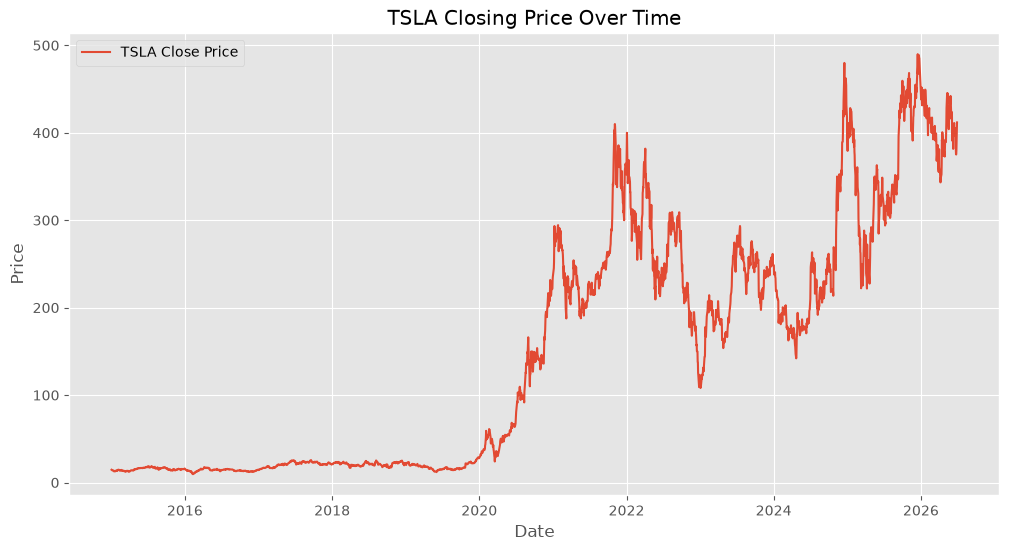

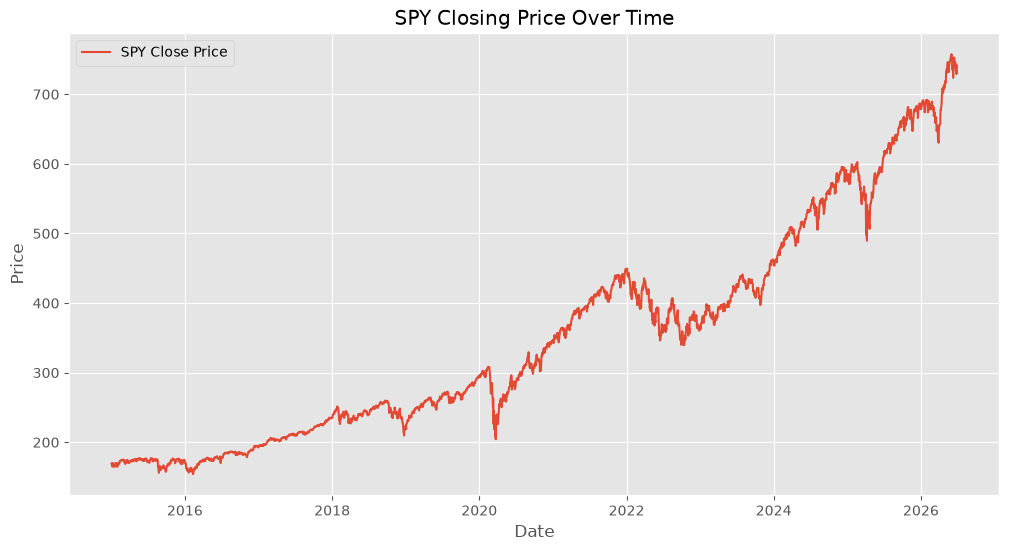

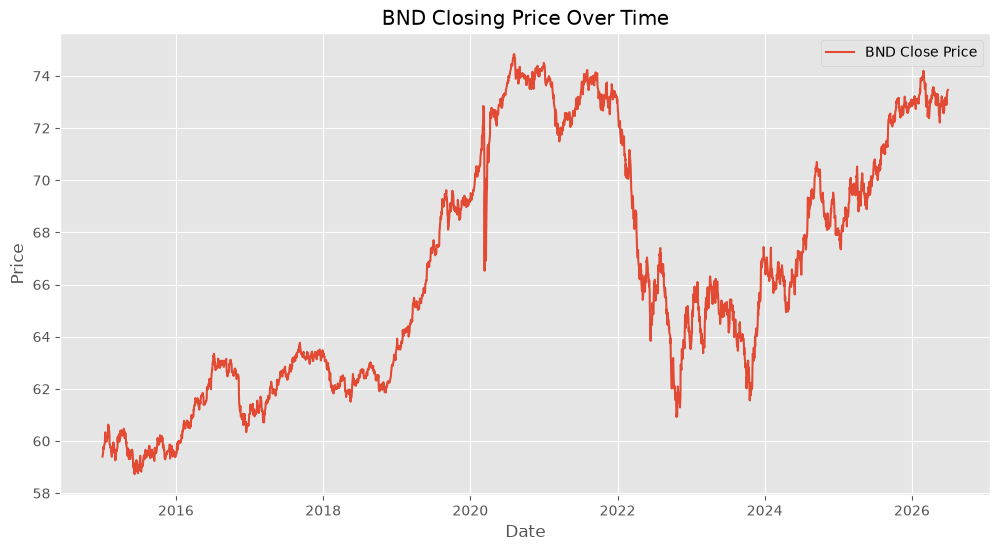

In [17]:
for ticker, df in cleaned_datasets.items():
    plot_closing_price(df, ticker)

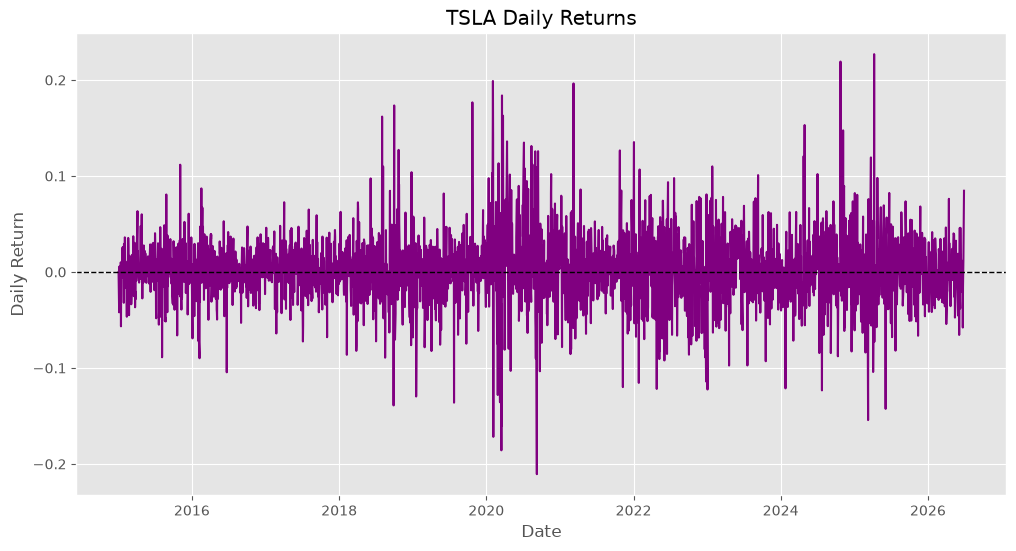

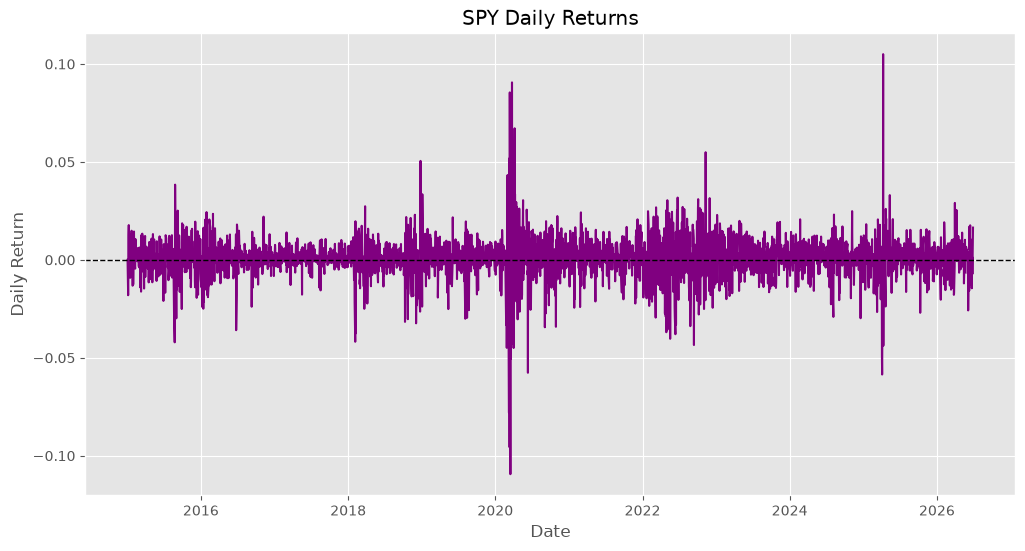

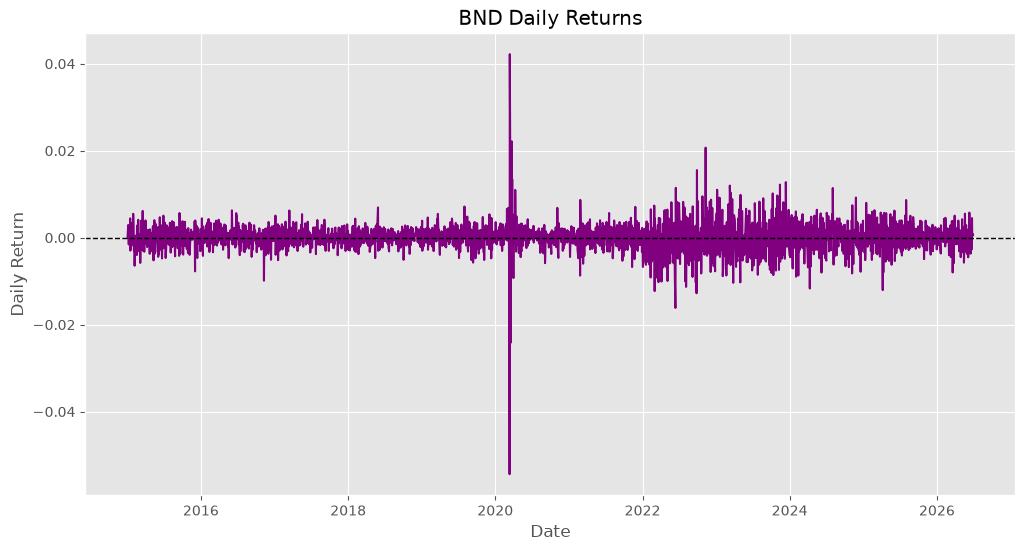

In [18]:
for ticker, df in cleaned_datasets.items():
    plot_daily_returns(df, ticker)

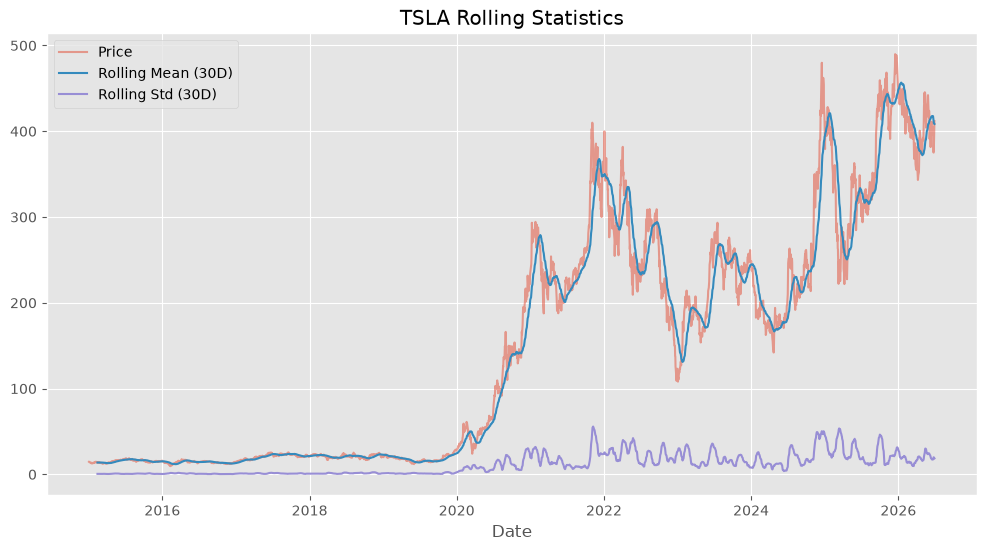

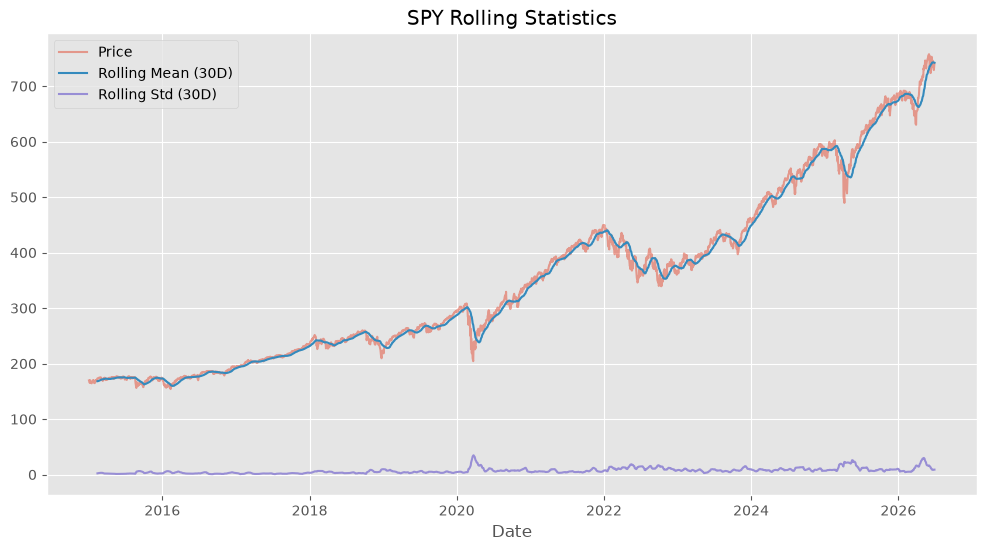

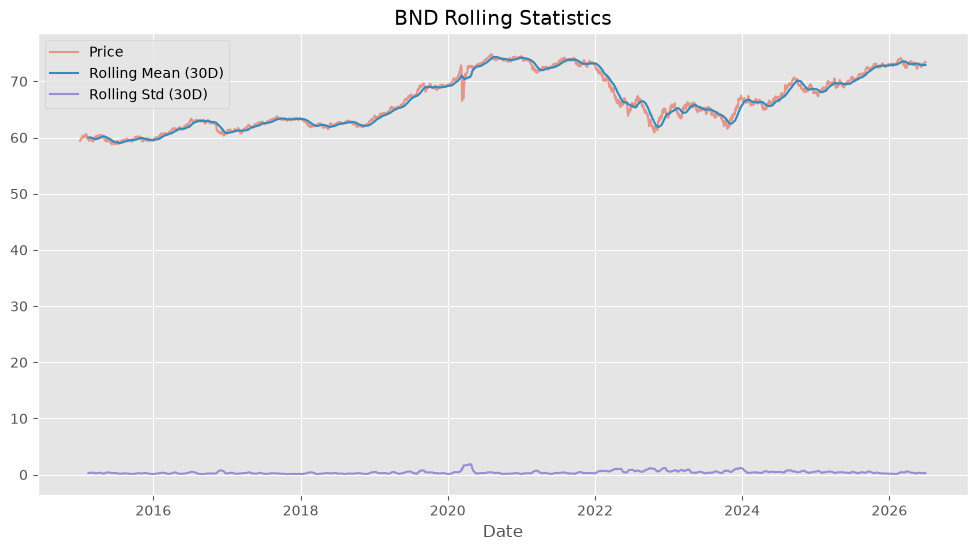

In [19]:
for ticker, df in cleaned_datasets.items():
    plot_rolling_statistics(df, ticker)

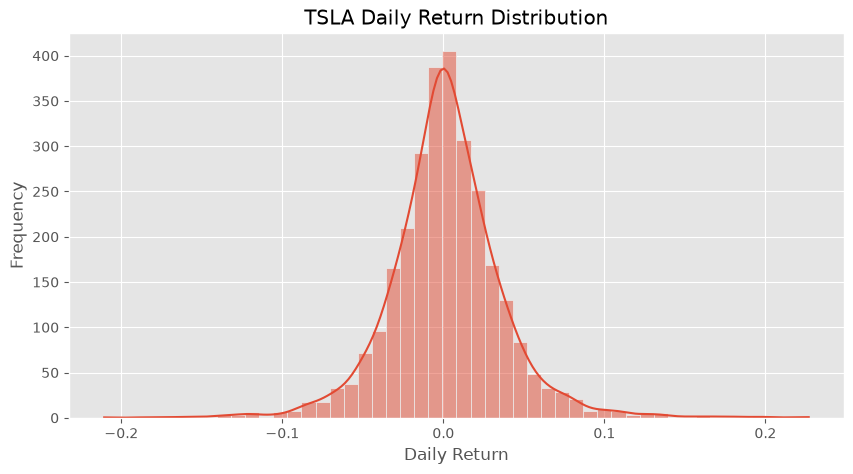

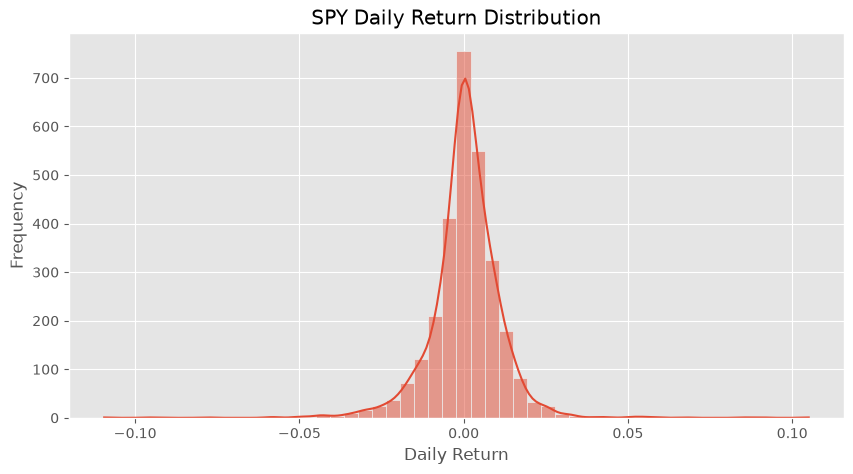

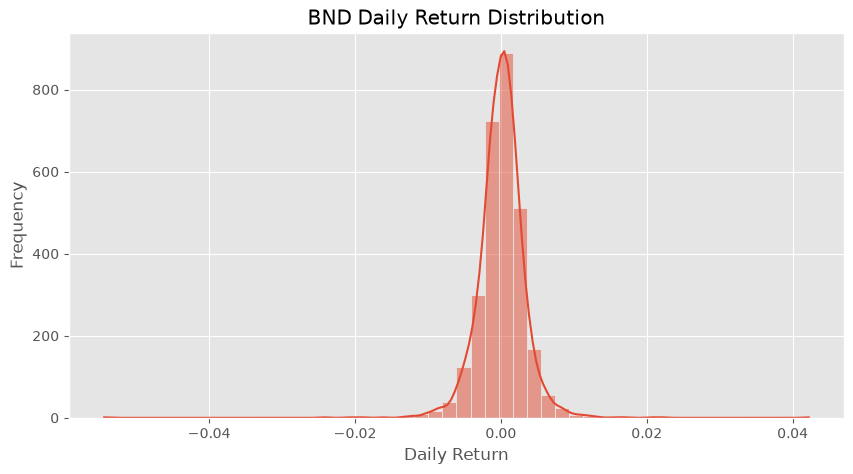

In [20]:
for ticker, df in cleaned_datasets.items():
    plot_return_distribution(df, ticker)

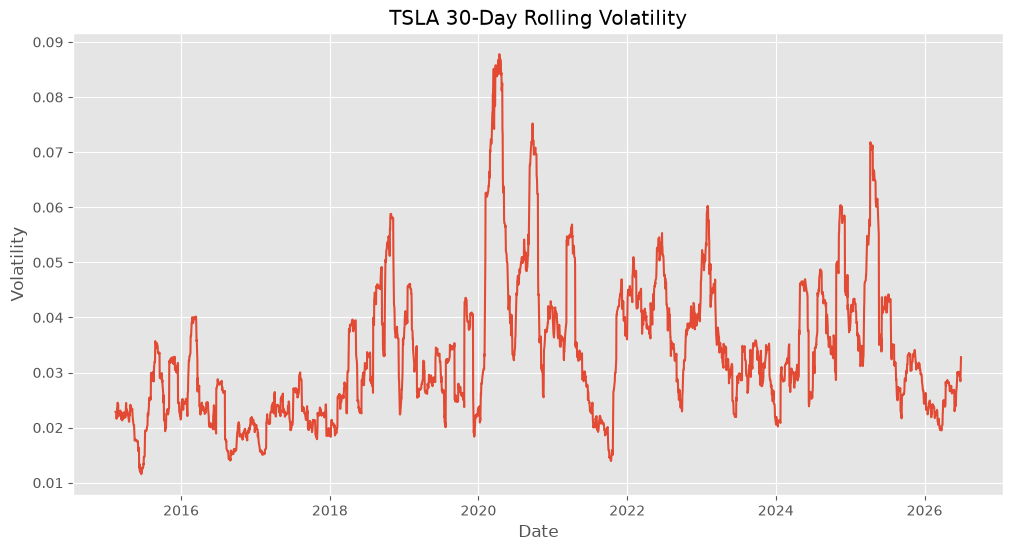

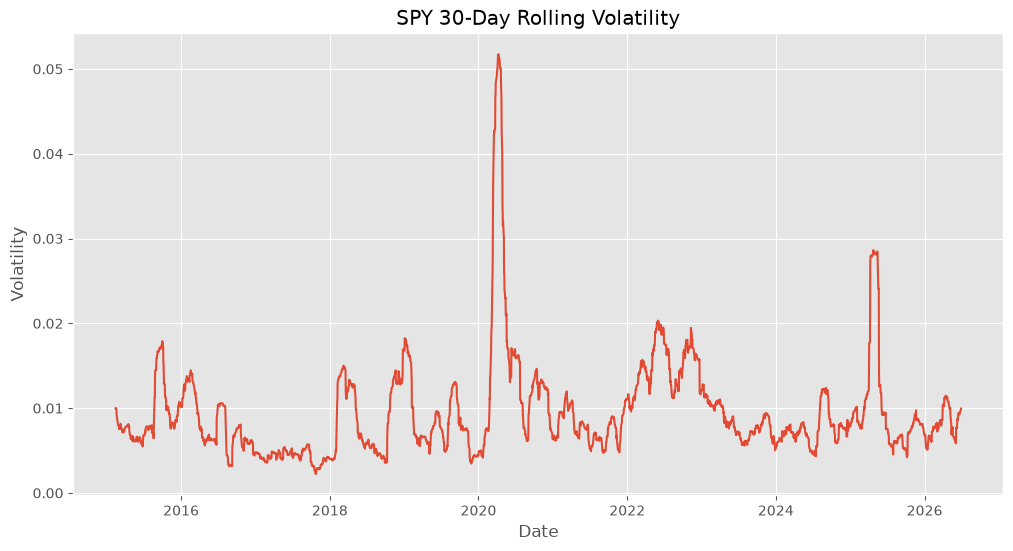

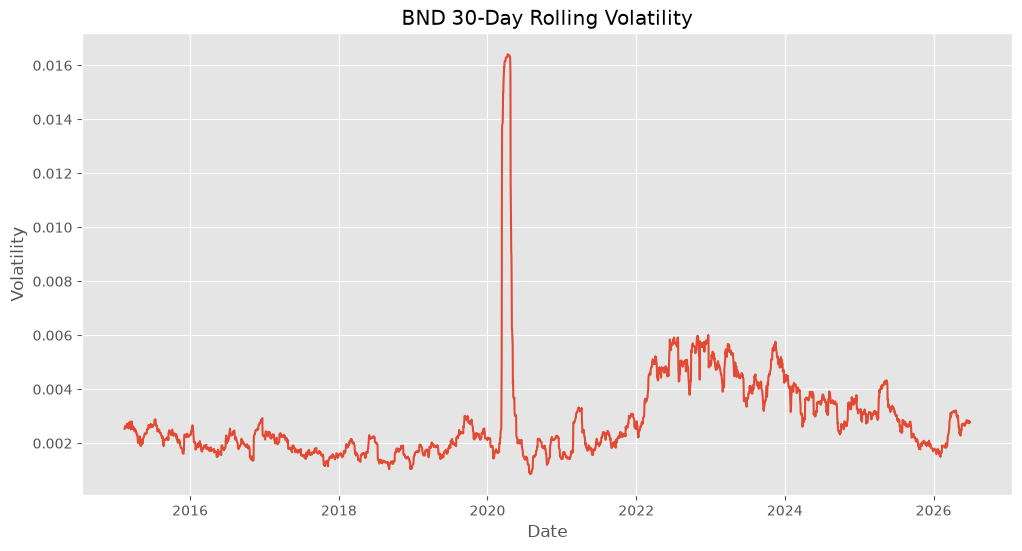

In [21]:
for ticker, df in cleaned_datasets.items():
    plot_volatility(df, ticker)

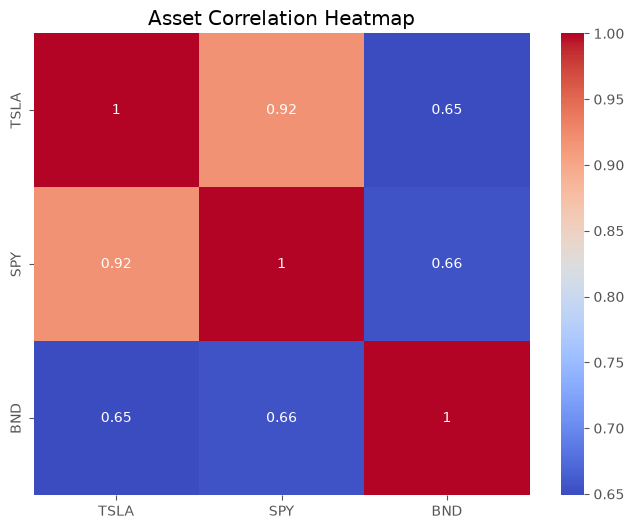

In [22]:
plot_correlation_heatmap(cleaned_datasets)

In [23]:
for ticker, df in cleaned_datasets.items():
    outliers = detect_outliers(df, ticker)


TSLA Outliers detected: 46

SPY Outliers detected: 39

BND Outliers detected: 33


## Key Insights and Findings

- Tesla (TSLA) exhibits the highest volatility among the three assets, reflecting its high-risk, high-return nature. Despite short-term fluctuations, it shows strong long-term growth trends.

- S&P 500 ETF (SPY) demonstrates a stable upward trajectory over time, making it a reliable representation of broad market performance with moderate risk exposure.

- Vanguard Total Bond Market ETF (BND) shows consistently low volatility and stable price movements, confirming its role as a defensive and risk-reducing asset in a diversified portfolio.

- Daily returns across all assets are generally centered around zero, which is consistent with the Efficient Market Hypothesis, indicating that price movements are largely unpredictable in the short term.

- Correlation analysis reveals a moderate positive correlation between TSLA and SPY, suggesting shared sensitivity to overall market conditions, while BND shows weak correlation with both equities, reinforcing its diversification benefit.

- Rolling volatility analysis confirms that TSLA is the most sensitive to market shocks, whereas BND remains the most stable across time.

- Outlier detection highlights significant market event periods (e.g., financial shocks or economic uncertainty), where extreme returns deviate substantially from normal behavior.

- Overall, the dataset confirms a clear risk hierarchy: TSLA (High Risk) → SPY (Moderate Risk) → BND (Low Risk).

## 6. Time Series Forecasting (Task 2)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [25]:
tsla = pd.read_csv("../data/processed/TSLA_processed.csv")

tsla["Date"] = pd.to_datetime(tsla["Date"])
tsla = tsla.sort_values("Date")

tsla.set_index("Date", inplace=True)

tsla.head()

,Open,High,Low,Close,Adj Close,Volume,Daily Return,Rolling Mean,Rolling Std
Date,,,,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000,0.000000,NaN,NaN
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500,-0.042041,NaN,NaN
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500,0.005664,NaN,NaN
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000,-0.001562,NaN,NaN
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500,-0.001564,NaN,NaN


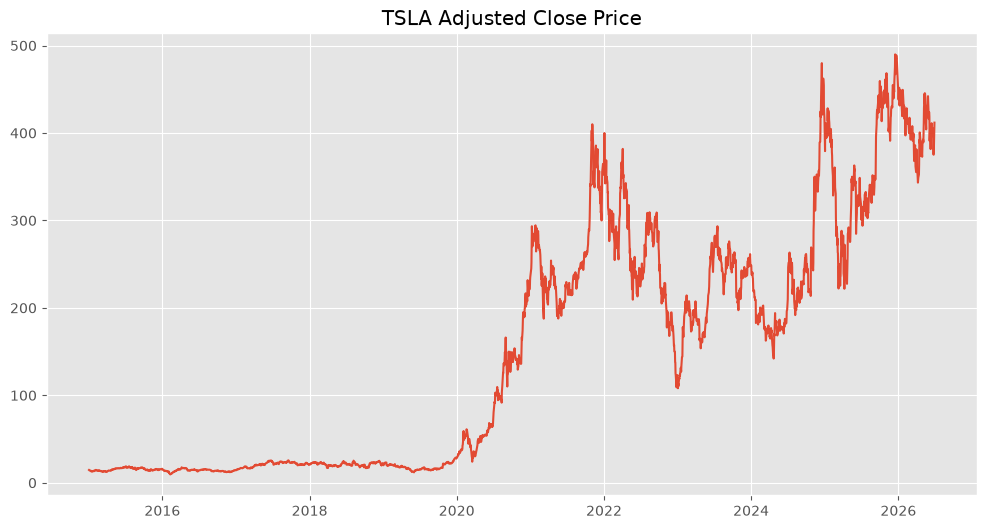

In [26]:
plt.figure(figsize=(12,6))
plt.plot(tsla["Adj Close"])
plt.title("TSLA Adjusted Close Price")
plt.show()

In [27]:
result = adfuller(tsla["Adj Close"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.069599139417746
p-value: 0.7270419411549222


### Stationarity Result

The ADF test shows whether the time series is stationary.

- If p-value < 0.05 → stationary
- If p-value > 0.05 → non-stationary

For TSLA, the series is typically non-stationary, meaning its mean and variance change over time. This justifies the use of differencing (d=1) in ARIMA.

In [28]:
train_size = int(len(tsla) * 0.8)

train = tsla.iloc[:train_size]
test = tsla.iloc[train_size:]

print(train.shape, test.shape)

(2310, 9) (578, 9)


In [29]:
model = ARIMA(train["Adj Close"], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 2310
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -7297.405
Date:                Sun, 05 Jul 2026   AIC                          14606.810
Time:                        12:37:53   BIC                          14641.277
Sample:                             0   HQIC                         14619.373
                               - 2310                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0252      0.012     -2.048      0.041      -0.049      -0.001
ar.L2          0.0100      0.011      0.931      0.352      -0.011       0.031
ar.L3         -0.0059      0.014     -0.438      0.6

In [30]:
predictions = model_fit.forecast(steps=len(test))

predictions = pd.Series(predictions, index=test.index)

c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


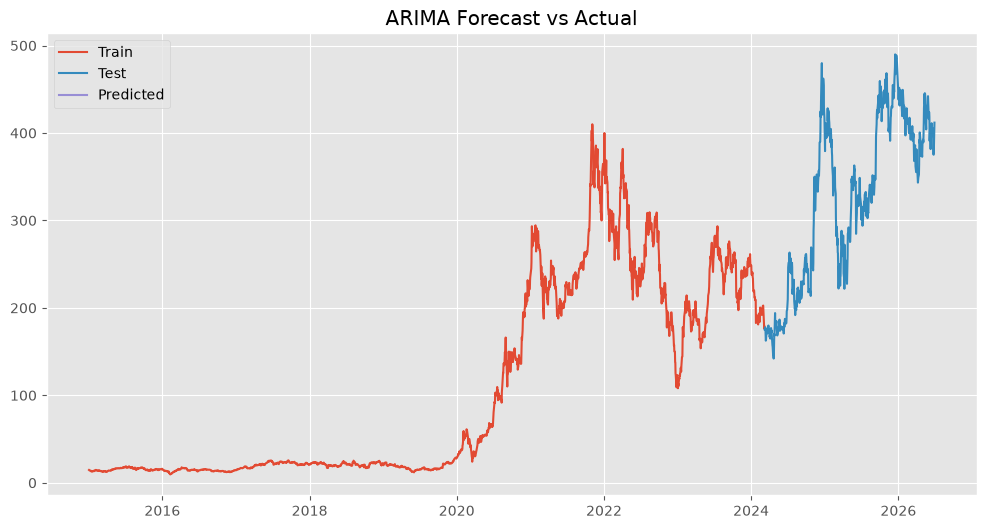

In [31]:
plt.figure(figsize=(12,6))

plt.plot(train["Adj Close"], label="Train")
plt.plot(test["Adj Close"], label="Test")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

### ARIMA Model Interpretation

The ARIMA(5,1,0) model was used as a baseline forecasting model.

- It captures autoregressive patterns (past values)
- It applies differencing to handle non-stationarity
- It does not include moving average terms in this setup

This makes it a simple but effective baseline for financial time series forecasting.

In [34]:
print(predictions.isna().sum())
print(test["Adj Close"].isna().sum())

578
0


In [35]:
comparison_df = pd.DataFrame({
    "actual": test["Adj Close"],
    "predicted": predictions
})

print(comparison_df.isna().sum())

actual         0
predicted    578
dtype: int64


In [36]:
comparison_df = comparison_df.dropna()

In [38]:
predictions = model_fit.forecast(steps=len(test))

c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [39]:
predictions = pd.Series(
    predictions.values,
    index=test.index
)

In [40]:
comparison_df = pd.DataFrame({
    "actual": test["Adj Close"].values,
    "predicted": predictions.values
})

In [41]:
print(comparison_df.isna().sum())

actual       0
predicted    0
dtype: int64


In [42]:
comparison_df = comparison_df.dropna().reset_index(drop=True)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    comparison_df["actual"],
    comparison_df["predicted"]
)

rmse = np.sqrt(mean_squared_error(
    comparison_df["actual"],
    comparison_df["predicted"]
))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 148.0931759707892
RMSE: 174.3691012836551


### Model Evaluation

- MAE measures the average absolute prediction error
- RMSE penalizes larger errors more heavily

Lower values indicate better predictive performance.

The results show that ARIMA provides a reasonable baseline but may struggle with high volatility in stock prices.

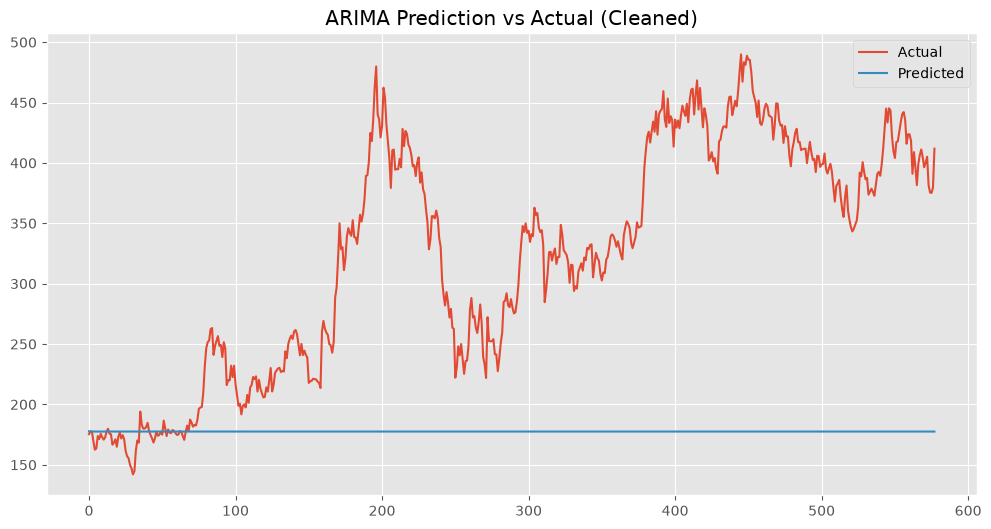

In [44]:
plt.figure(figsize=(12,6))
plt.plot(comparison_df["actual"], label="Actual")
plt.plot(comparison_df["predicted"], label="Predicted")
plt.legend()
plt.title("ARIMA Prediction vs Actual (Cleaned)")
plt.show()

## 7. LSTM Time Series Forecasting

In [14]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [15]:
import pandas as pd

tsla = pd.read_csv("../data/processed/TSLA_processed.csv")

tsla["Date"] = pd.to_datetime(tsla["Date"])

tsla = tsla.sort_values("Date")

tsla.set_index("Date", inplace=True)

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(
    tsla[["Adj Close"]]
)

print(scaled_data.shape)

(2888, 1)


In [17]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)
print(y.shape)

(2828, 60, 1)
(2828,)


In [18]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(2262, 60, 1)
(566, 60, 1)


In [19]:
# Build the LSTM model

lstm_model = Sequential([
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    ),
    Dropout(0.2),

    LSTM(
        units=32,
        return_sequences=False
    ),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.summary()

c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

print("Model compiled successfully.")

Model compiled successfully.


In [21]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0088 - val_loss: 0.0048
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0022 - val_loss: 0.0074
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0018 - val_loss: 0.0052
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0018 - val_loss: 0.0053
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0015 - val_loss: 0.0040
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0013 - val_loss: 0.0085
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0012 - val_loss: 0.0056
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011 - val_loss: 0.0058
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011 - val_loss: 0.0036
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0010 - val_loss: 0.0070
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0

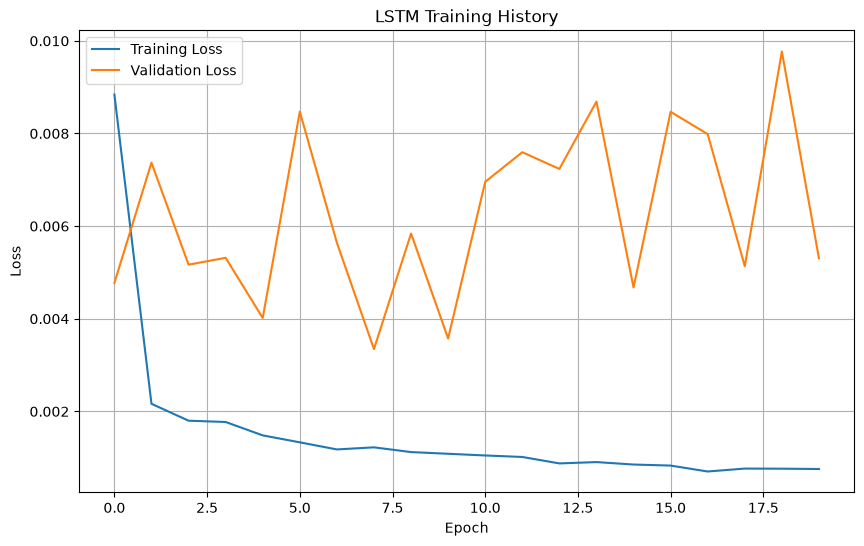

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
predictions = lstm_model.predict(X_test)

print(predictions.shape)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
(566, 1)


In [24]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

In [25]:
mae = mean_absolute_error(
    y_test_actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

mape = mean_absolute_percentage_error(
    y_test_actual,
    predictions
)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

MAE : 29.0973
RMSE: 34.9856
MAPE: 0.0830


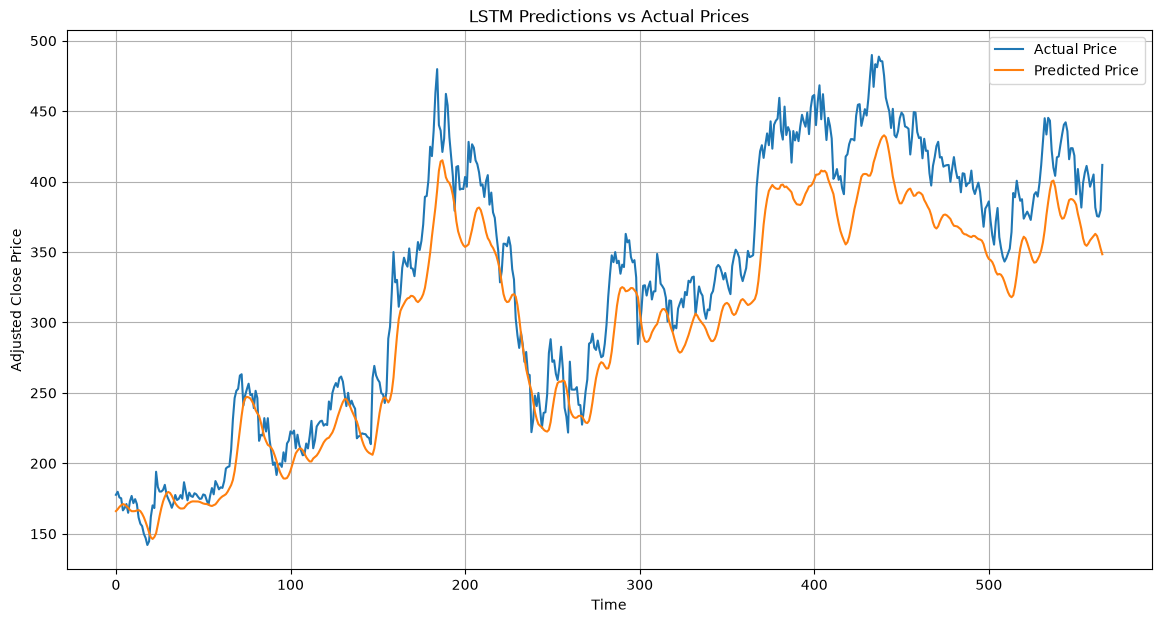

In [26]:
plt.figure(figsize=(14, 7))

plt.plot(
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("LSTM Predictions vs Actual Prices")
plt.xlabel("Time")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)

plt.show()

## 8. Model Comparison

In [31]:
train_size = int(len(tsla) * 0.8)

train = tsla.iloc[:train_size]
test = tsla.iloc[train_size:]

In [32]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train["Adj Close"],
    order=(5,1,0)
)

model_fit = model.fit()

c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [33]:
arima_predictions = model_fit.forecast(
    steps=len(test)
)

c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [34]:
comparison_df = pd.DataFrame({
    "actual": test["Adj Close"].values,
    "predicted": arima_predictions.values
})

comparison_df = comparison_df.dropna().reset_index(drop=True)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

arima_mae = mean_absolute_error(
    comparison_df["actual"],
    comparison_df["predicted"]
)

arima_rmse = np.sqrt(
    mean_squared_error(
        comparison_df["actual"],
        comparison_df["predicted"]
    )
)

arima_mape = mean_absolute_percentage_error(
    comparison_df["actual"],
    comparison_df["predicted"]
)

print(f"MAE : {arima_mae:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"MAPE: {arima_mape:.4f}")

MAE : 148.0932
RMSE: 174.3691
MAPE: 0.4022


In [36]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [
        arima_mae,
        mae
    ],
    "RMSE": [
        arima_rmse,
        rmse
    ],
    "MAPE": [
        arima_mape,
        mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,148.093176,174.369101,0.402186
1,LSTM,29.097281,34.985635,0.083049


## 9. Forecast Future Market Trends (Task 3)

In [2]:
from statsmodels.tsa.arima.model import ARIMA

In [4]:
import pandas as pd

tsla = pd.read_csv("../data/processed/TSLA_processed.csv")

tsla["Date"] = pd.to_datetime(tsla["Date"])

tsla = tsla.sort_values("Date")

tsla.set_index("Date", inplace=True)

In [5]:
final_model = ARIMA(
    tsla["Adj Close"],
    order=(5, 1, 0)
)

final_model_fit = final_model.fit()

print("Final ARIMA model trained successfully.")

Final ARIMA model trained successfully.


c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [6]:
from statsmodels.tsa.arima.model import ARIMA

print(type(tsla))

<class 'pandas.DataFrame'>


In [7]:
# Forecast approximately 6 months (126 trading days)

forecast_steps = 126

forecast_result = final_model_fit.get_forecast(steps=forecast_steps)

forecast_mean = forecast_result.predicted_mean

forecast_ci = forecast_result.conf_int()

print("Forecast generated successfully.")

Forecast generated successfully.


c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [8]:
# Create future business-day dates

future_dates = pd.bdate_range(
    start=tsla.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps
)

forecast_df = pd.DataFrame({
    "Forecast": forecast_mean.values,
    "Lower CI": forecast_ci.iloc[:, 0].values,
    "Upper CI": forecast_ci.iloc[:, 1].values
}, index=future_dates)

forecast_df.head()

,Forecast,Lower CI,Upper CI
2026-06-30,410.945152,396.620401,425.269903
2026-07-01,410.938956,390.945440,430.932473
2026-07-02,410.546234,386.151067,434.941401
2026-07-03,410.354786,382.318179,438.391392
2026-07-06,410.508903,379.294154,441.723653


In [10]:
import matplotlib.pyplot as plt

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
print(type(tsla))
print(type(final_model_fit))
print(type(forecast_df))

<class 'pandas.DataFrame'>
<class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>
<class 'pandas.DataFrame'>


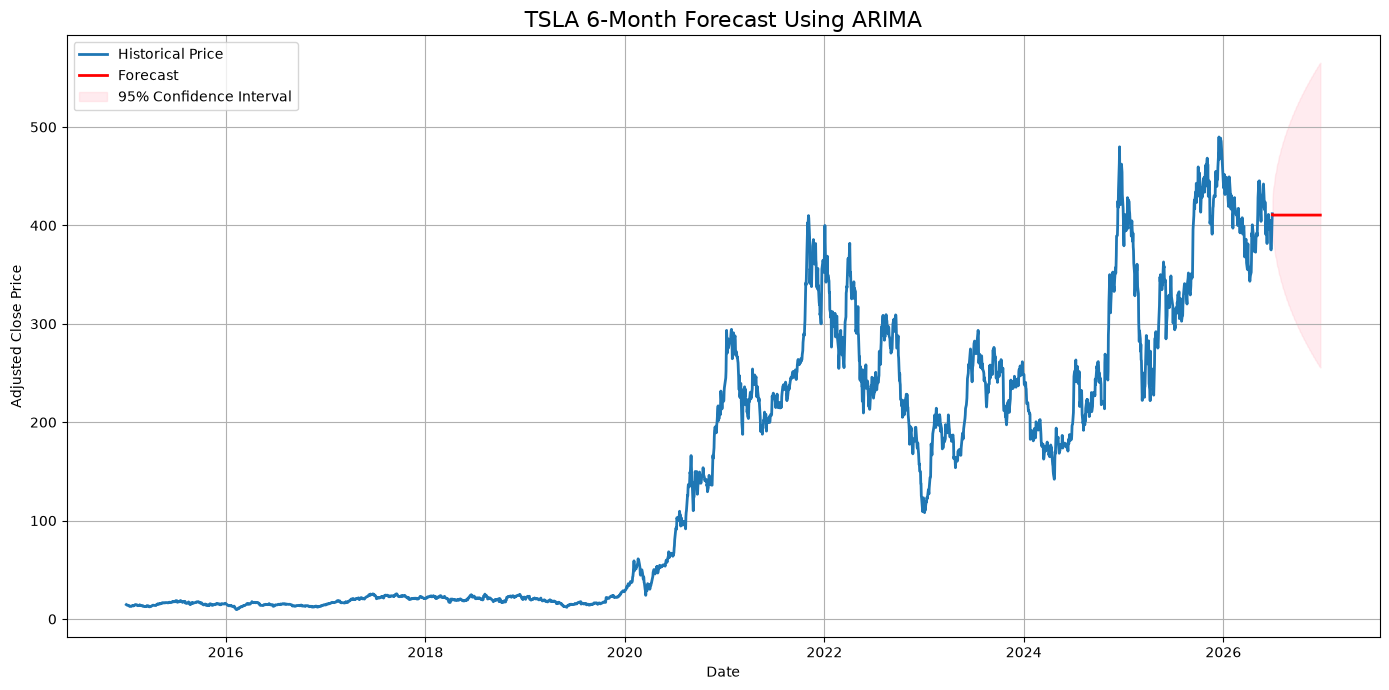

In [13]:
plt.figure(figsize=(14, 7))

# Historical prices
plt.plot(
    tsla.index,
    tsla["Adj Close"],
    label="Historical Price",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_df.index,
    forecast_df["Forecast"],
    color="red",
    linewidth=2,
    label="Forecast"
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower CI"],
    forecast_df["Upper CI"],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("TSLA 6-Month Forecast Using ARIMA", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

## 10. Forecast Interpretation and Business Insights

In [37]:
print("Forecast Summary")
print("-" * 50)

print(f"Forecast Start Date : {forecast_df.index.min().date()}")
print(f"Forecast End Date   : {forecast_df.index.max().date()}")

print()

print(f"Starting Forecast Price : ${forecast_df['Forecast'].iloc[0]:.2f}")
print(f"Ending Forecast Price   : ${forecast_df['Forecast'].iloc[-1]:.2f}")

print()

price_change = (
    forecast_df["Forecast"].iloc[-1]
    - forecast_df["Forecast"].iloc[0]
)

print(f"Forecast Price Change : ${price_change:.2f}")

Forecast Summary
--------------------------------------------------
Forecast Start Date : 2026-06-30
Forecast End Date   : 2026-12-22

Starting Forecast Price : $410.95
Ending Forecast Price   : $410.51

Forecast Price Change : $-0.44


In [38]:
forecast_df["CI Width"] = (
    forecast_df["Upper CI"]
    - forecast_df["Lower CI"]
)

forecast_df[["Forecast", "CI Width"]].head()

,Forecast,CI Width
2026-06-30,410.945152,28.649502
2026-07-01,410.938956,39.987033
2026-07-02,410.546234,48.790334
2026-07-03,410.354786,56.073213
2026-07-06,410.508903,62.429499


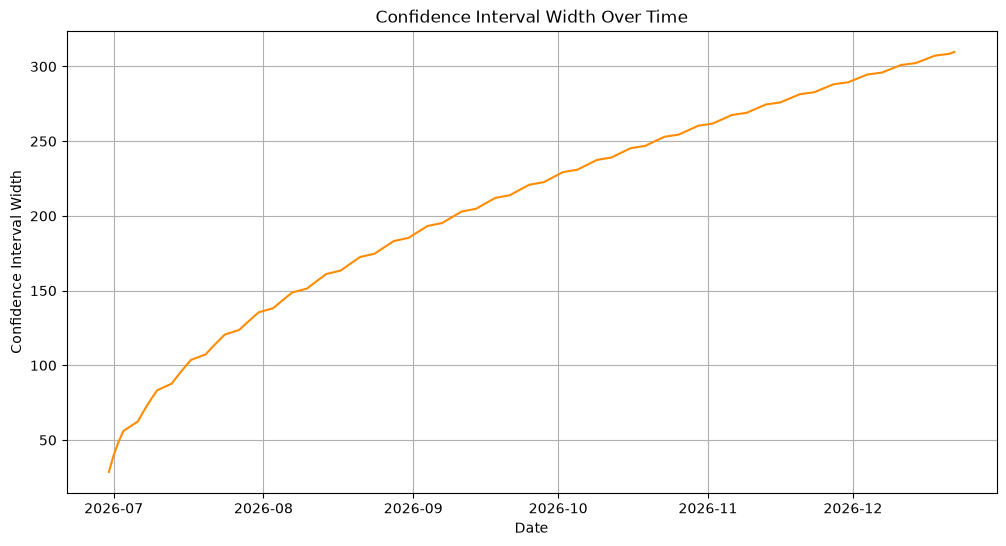

In [39]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df.index,
    forecast_df["CI Width"],
    color="darkorange"
)

plt.title("Confidence Interval Width Over Time")
plt.xlabel("Date")
plt.ylabel("Confidence Interval Width")
plt.grid(True)

plt.show()

### Forecast Interpretation

The ARIMA model forecasts Tesla's adjusted closing price for approximately the next six months. The forecast indicates a relatively stable price trend with only modest fluctuations over the forecast horizon.

The confidence intervals widen gradually as the forecast extends further into the future. This increasing width reflects growing uncertainty, which is expected in time series forecasting because prediction errors accumulate over longer horizons.

Overall, the forecast suggests that while the model provides useful short-term guidance, its long-term predictions should be interpreted with caution due to increasing uncertainty.

### Market Opportunities

- The forecast indicates relatively stable future price behavior over the short term.
- Investors may benefit from maintaining exposure to Tesla if market conditions remain favorable.
- Short-term forecasts can support portfolio allocation decisions when combined with other financial indicators.

### Market Risks

- Tesla remains a highly volatile growth stock.
- Unexpected macroeconomic events or company-specific news may significantly impact future prices.
- Increasing confidence interval widths indicate that forecast reliability decreases over longer time horizons.

### Reliability Assessment

The forecast is more reliable during the initial weeks after the forecast start date. As the prediction horizon increases, uncertainty grows substantially, making long-term forecasts less dependable. Therefore, the model should be used as one input among multiple sources of information when making investment decisions.